## Лабораторна робота 4. **REGRESSION** 📈

# Опис вибірки "Motorbike Ambulance Calls"


Аварії за участю мотоциклів та відповідні виклики швидкої допомоги сильно залежать від екологічних та сезонних умов, таких як погодні умови, опади, день тижня, сезон, година дня тощо. Дані збирались протягом двох років щогодини та потім співвідносилися з відповідною погодою та сезонністю.

Основні характеристики вибірки `motorbike_ambulance_calls.csv`:

              - index: record index
              - date : date
              - season : season (1:springer, 2:summer, 3:fall, 4:winter)
              - yr : year (0: 2011, 1:2012)
              - mnth : month ( 1 to 12)
              - hr : hour (0 to 23)
              - holiday : whether day is holiday or not
              - weekday : day of the week
              - workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
              -  weathersit :
                      - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
                      - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
                      - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
                      - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
              - temp : Normalized temperature in Celsius. The values are divided to 41 (max)
              - atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
              - hum: Normalized humidity. The values are divided to 100 (max)
              - windspeed: Normalized wind speed. The values are divided to 67 (max)
              - cnt: count of total ambulance calls

## Імпорт необхідних бібліотек та завантаження даних

**Завдання 1** підготовка даних до опрацювання

1. завантажте вибірку `motorbike_ambulance_calls.csv`;   
2. підключіть необхідні бібліотеки;  
3. вивести основну статистичну інформацію по числовим змінним;  
4. окремо вивести максимальні та мінімальні значення по всім змінним;  
5. вивести розмірність датасету;

In [1]:
import pandas as pd
import numpy as np
import scipy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
%matplotlib inline

In [2]:
def get_data(data_path: str):
    df = pd.read_csv(data_path)
    return df

df = get_data("/content/sample_data/motorbike_ambulance_calls.csv")
print(df)

       index      date  season  yr  mnth  hr  holiday  weekday  workingday  \
0          1    1/1/11  spring   0     1   0        0        6           0   
1          2    1/1/11  spring   0     1   1        0        6           0   
2          3    1/1/11  spring   0     1   2        0        6           0   
3          4    1/1/11  spring   0     1   3        0        6           0   
4          5    1/1/11  spring   0     1   4        0        6           0   
...      ...       ...     ...  ..   ...  ..      ...      ...         ...   
17374  17375  12/31/12  spring   1    12  19        0        1           1   
17375  17376  12/31/12  spring   1    12  20        0        1           1   
17376  17377  12/31/12  spring   1    12  21        0        1           1   
17377  17378  12/31/12  spring   1    12  22        0        1           1   
17378  17379  12/31/12  spring   1    12  23        0        1           1   

       weathersit  temp   atemp   hum  windspeed  cnt  
0      

**Завдання 2** перевірити типи даних та перевірте кількість даних по кожній змінній.

In [3]:
print("Типи даних:")
print(df.info())

print("Кількість даних по кожній змінній:")
print(df.count())

Типи даних:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       17379 non-null  int64  
 1   date        17379 non-null  object 
 2   season      17379 non-null  object 
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(2)
memory usage: 2.0+ MB
None
Кількість даних по кожній змінній:
index         17379
date          17379
season        17379
yr            17379


**Завдання 3** пепевірте всі змінні на наявність пропусків.

In [4]:
print("Пропуски у кожній змінній:")
print(df.isnull().sum())

Пропуски у кожній змінній:
index         0
date          0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64


**Висновки з 1-3 завдання (детальні)**



1. Завантажили вибірку motorbike_ambulance_calls.csv, імпортували потрібні нам бібліотеки та вказали шлях до нашого csv файлу
2. Перевірили типи даних (отримали int64, float64 і object), та кількість даних у кожній змінній, можемо побачити що у кожній є одинакова кількість значень
3. Перевірили пропуски у всіх змінних за допомогою методів isnull і sum, отримали біля кожної 0, тобто це означає що в жодному стовпці немає пропущених значень



**Завдання 4** перетворіть змінну `date` в **date type**. Визначте часові межі датасету.

In [5]:
def transform_date(df: pd.DataFrame, date_col_name: str):
    df[date_col_name] = pd.to_datetime(df[date_col_name], format='%Y-%m-%d %H:%M:%S')

    return df

In [6]:
def get_time_limits(df: pd.DataFrame, date_col_name: str):
    first_day = df[date_col_name].min()
    last_day = df[date_col_name].max()
    print(f"First day - {first_day}")
    print(f"Last day - {last_day}")

get_time_limits(df, 'date')

First day - 1/1/11
Last day - 9/9/12


Перетворили змінну date в data type за допомогою функції transform_date, перевірити це можемо за допомогою print(df.dtypes), та бачимо що біля date стоїть datetime64(ns) - один з типів даних для data type.

Визначили часові межі за допомогою фукнції get_time_limits, бачимо що first day - 2011.01.01, last day - 2012-12-31

#Аналіз категоріальних змінних

**Завдання 5** виділити категоріальні змінні в окремий датасет







In [7]:
categorical_columns = ["season", "weathersit", "weekday", "mnth"]

df_categorical = df[categorical_columns]

print(df_categorical)

       season  weathersit  weekday  mnth
0      spring           1        6     1
1      spring           1        6     1
2      spring           1        6     1
3      spring           1        6     1
4      spring           1        6     1
...       ...         ...      ...   ...
17374  spring           2        1    12
17375  spring           2        1    12
17376  spring           1        1    12
17377  spring           1        1    12
17378  spring           1        1    12

[17379 rows x 4 columns]


**Завдання 6** перетворіть змінну `season` в числову шкалу.

In [8]:
def encode_season(df: pd.DataFrame, season: str):
    mapping = {"spring": 1, "summer": 2, "autumn": 3, "winter": 4}
    df[season] = df[season].map(mapping)
    df = df.dropna(subset=[season])
    df[season] = df[season].astype(int)
    return df

**Завдання 7** побудувати графіки `countplot` по всім категоріальним змінним

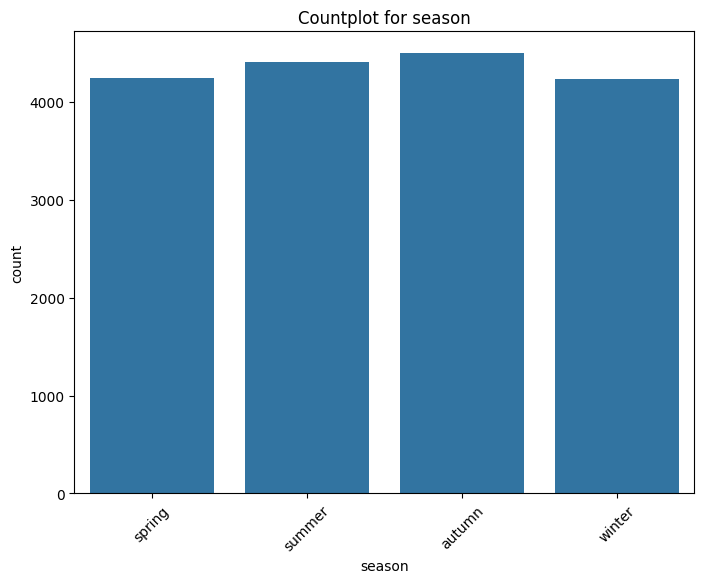

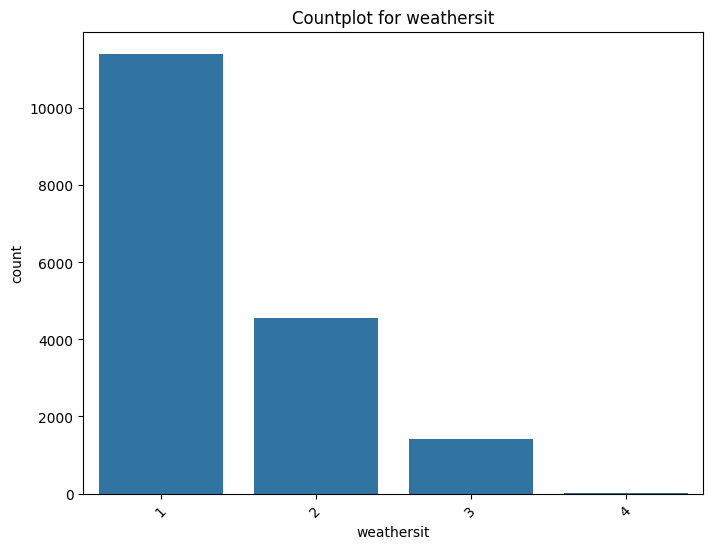

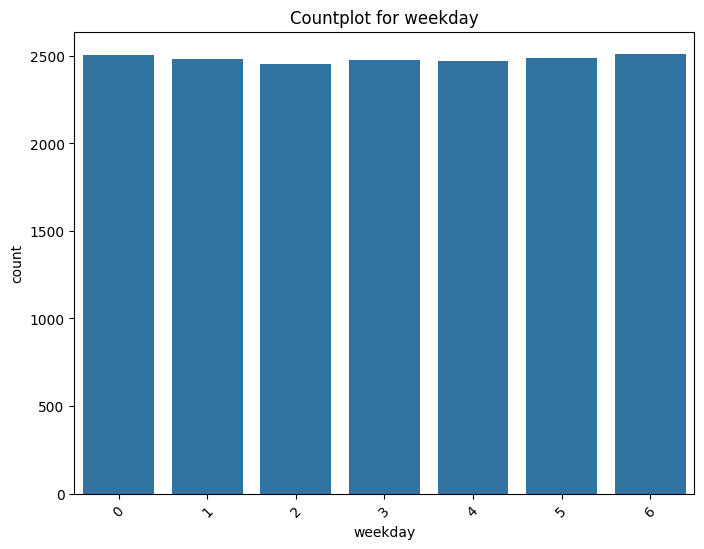

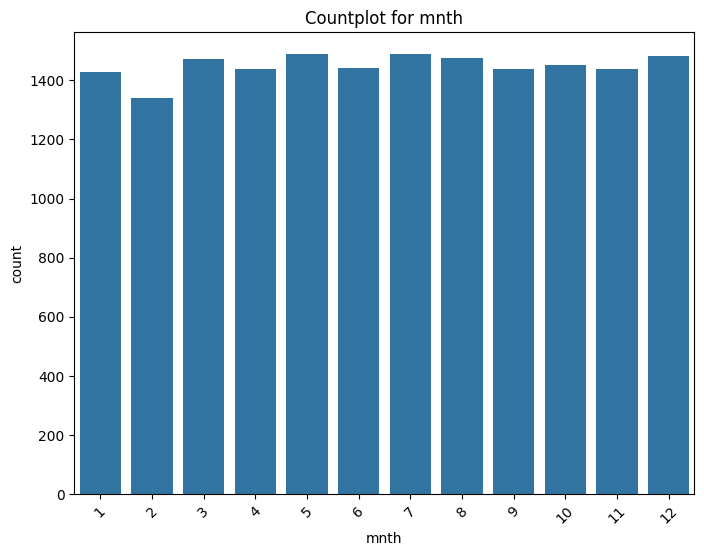

In [9]:
def plot_countplots(df: pd.DataFrame, categorical_columns: list):
    for column in categorical_columns:
        plt.figure(figsize=(8, 6))
        sns.countplot(x=column, data=df)
        plt.title(f'Countplot for {column}')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(df, categorical_columns)

**Висновки з 5-7 завдання (детальні)**

5. Спочатку визначили які змінні у нас категоріальні за допомогою df.select_dtypes=["object", "category"], нам вивело 4 змінні, а саме: season, weathersit, weekday, mnth. Після цього виділили їх в окремий датасет.

6. Перетворили змінну season у числову шкалу за допомогою маппінгу, де вказали що Spring - 1, Summer - 2, Autumn - 3, Winter - 4.

7. Створили та відобразили графіки по всіх категоріальних змінних.



#Аналіз числових змінних

**Завдання 8** виділити числові змінні в окремий датасет

In [10]:
data_numerical = df.select_dtypes(include=['int64', 'float64'])

print(data_numerical.head())

   index  yr  mnth  hr  holiday  weekday  workingday  weathersit  temp  \
0      1   0     1   0        0        6           0           1  0.24   
1      2   0     1   1        0        6           0           1  0.22   
2      3   0     1   2        0        6           0           1  0.22   
3      4   0     1   3        0        6           0           1  0.24   
4      5   0     1   4        0        6           0           1  0.24   

    atemp   hum  windspeed  cnt  
0  0.2879  0.81        0.0   16  
1  0.2727  0.80        0.0   40  
2  0.2727  0.80        0.0   32  
3  0.2879  0.75        0.0   13  
4  0.2879  0.75        0.0    1  


**Завдання 9** побудуйте гістограми розподілу по всім числовим змінним

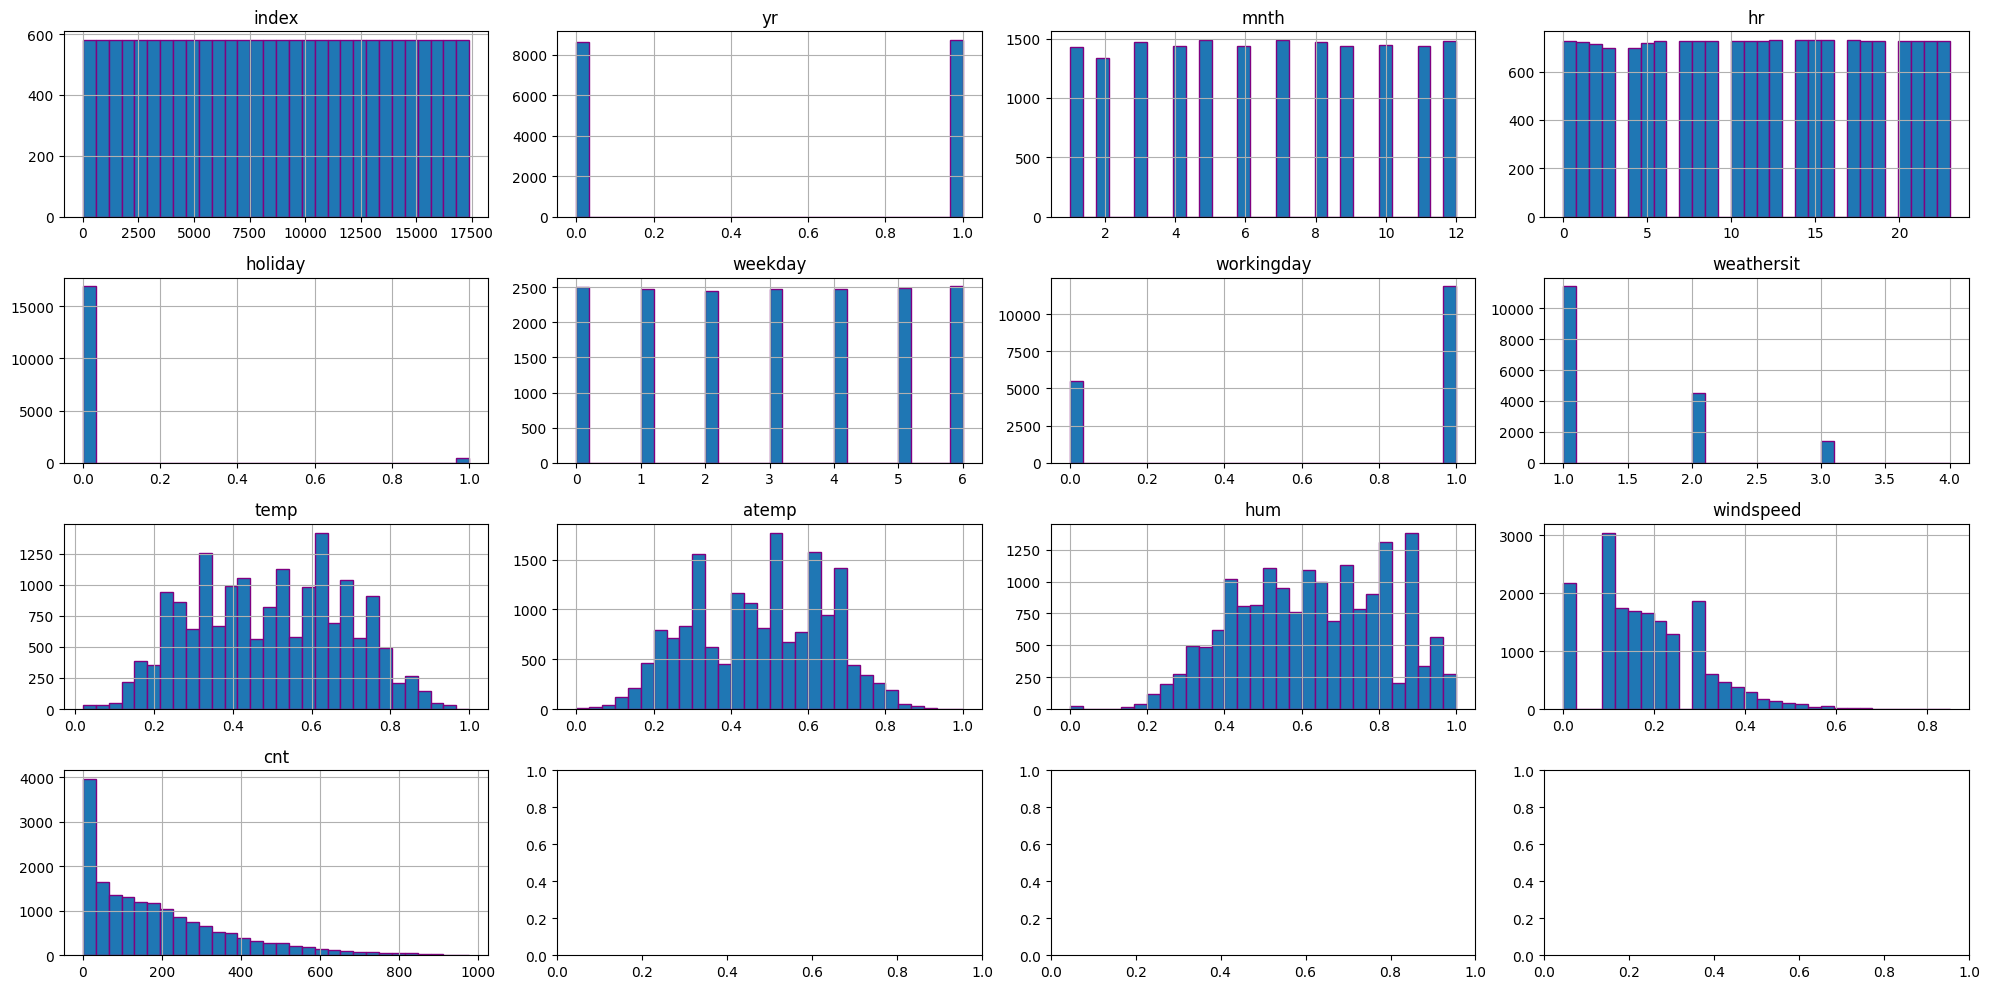

In [11]:
fig, ax = plt.subplots(4, 4, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(data_numerical.columns):
    data_numerical[col].hist(ax=ax[i], bins=30, edgecolor='purple')
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

**Завдання 10** побудуйте гістограму розподілу цільової змінної та розрахуйте коефіціент нахилу

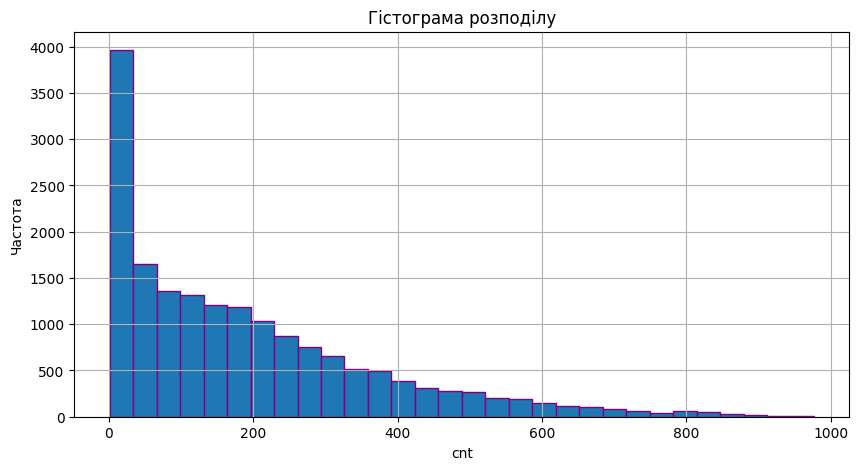

Коефіцієнт нахилу: 1.2773013463494975


In [12]:
plt.figure(figsize=(10, 5))
df["cnt"].hist(bins=30, edgecolor="purple")
plt.title("Гістограма розподілу")
plt.xlabel("cnt")
plt.ylabel("Частота")
plt.show()

skewness = skew(df["cnt"])
print(f"Коефіцієнт нахилу: {skewness}")

**Висновки з 8-10 завдання (детальні)**

8. Виділили числові змінні в окремий датасет за допомогою int i float. Отримали: index, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, cnt.

9. Створили та відобразили гістограми розподілу по всіх числових змінних.

10. Створили гістограму розподілу, вирахували коефіцієнт нахилу за допомогою skewness, отримали 1.277

#Аналіз взаємозв'язків між числовими і категоріальними змінними

**Завдання 11** побудуйте графіки співвідношення `scatterplot` між всіма числовими змінними і цільовою змінною `cnt`

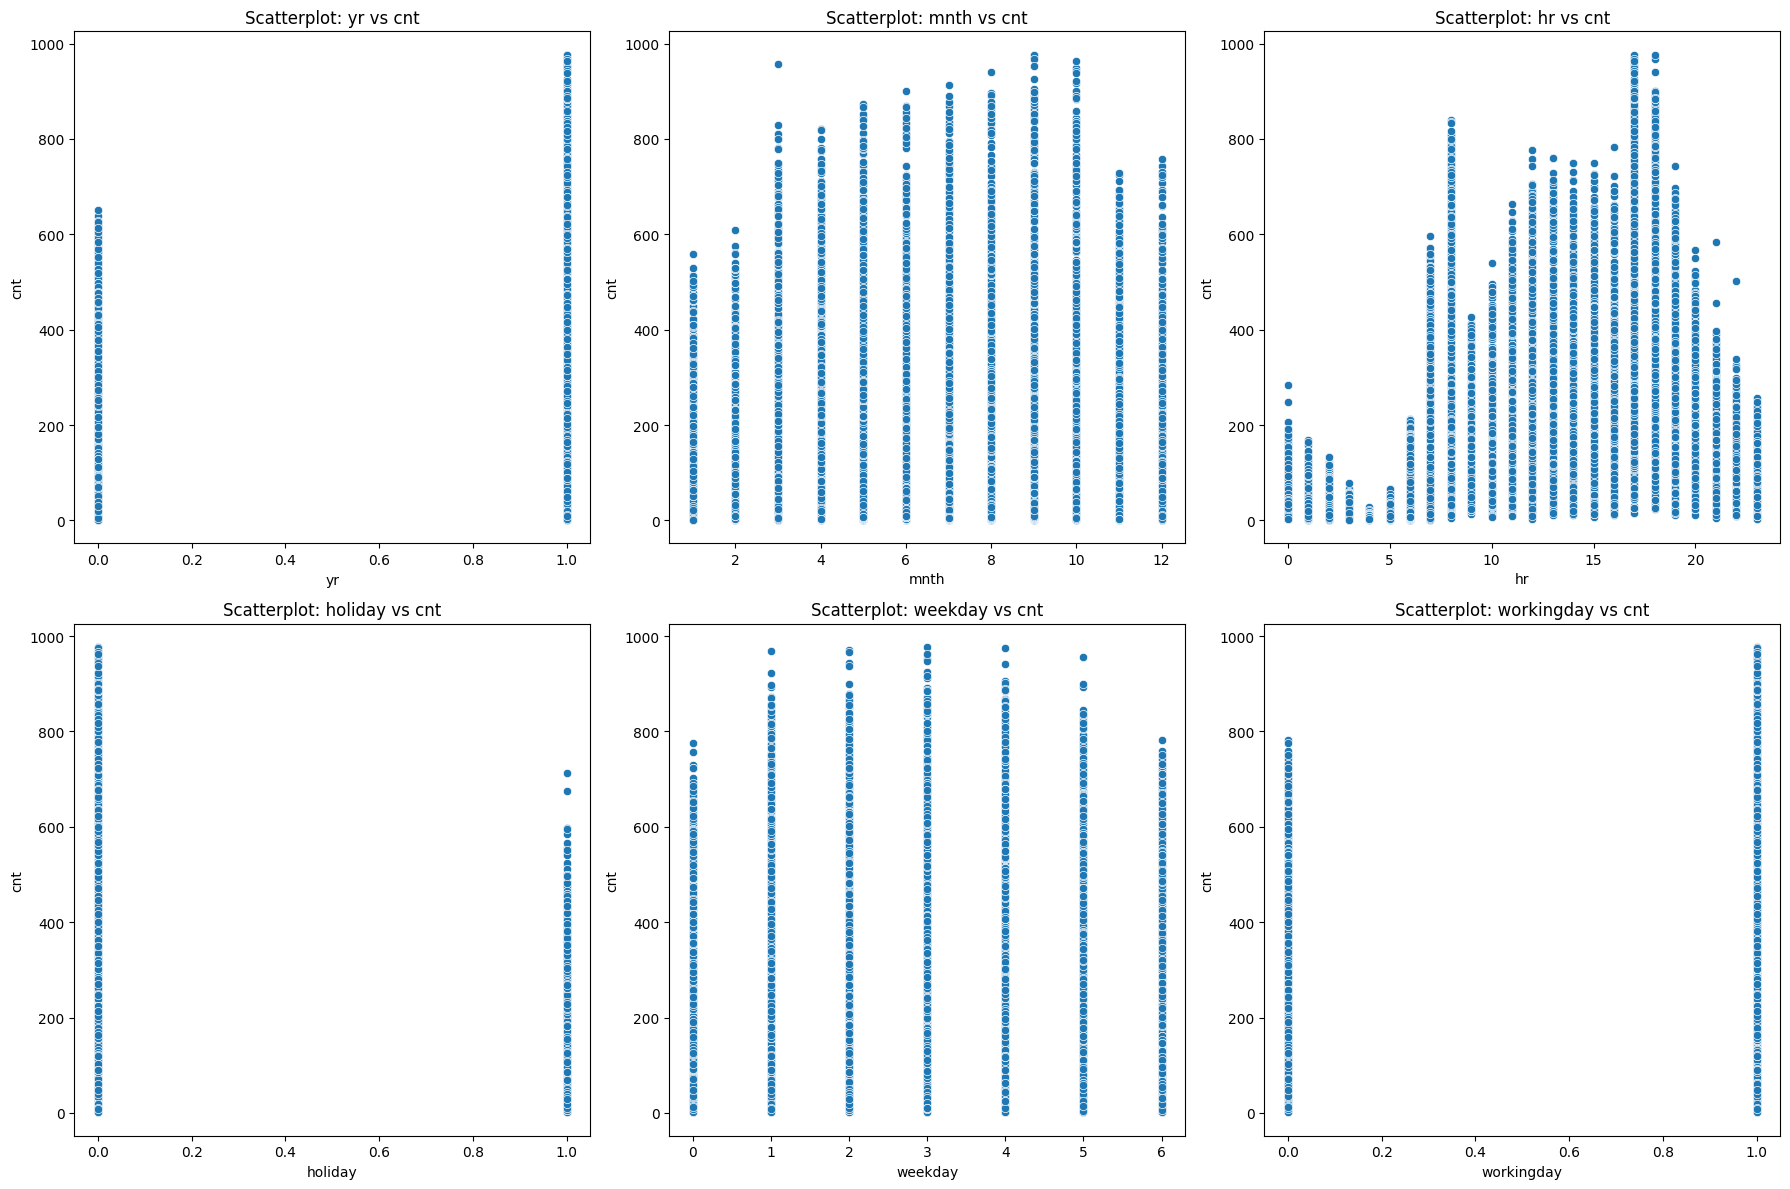

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(18, 12))

for var, subplot in zip(['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday'], ax.flatten()):
    sns.scatterplot(x=data_numerical[var], y=data_numerical['cnt'], ax=subplot)
    subplot.set_title(f"Scatterplot: {var} vs cnt")

plt.tight_layout()
plt.show()

**Завдання 12** побудуйте графіки співвідношення `boxplot`[boxplot](https://matplotlib.org/stable/gallery/statistics/boxplot_demo.html) між категоріальними змінними і цільовою змінною `cnt`.

<ipython-input-17-42e0a29c9ceb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=df["cnt"], data=df, palette='viridis', ax=subplot)
<ipython-input-17-42e0a29c9ceb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=df["cnt"], data=df, palette='viridis', ax=subplot)
<ipython-input-17-42e0a29c9ceb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=df["cnt"], data=df, palette='viridis', ax=subplot)
<ipython-input-17-42e0a29c9ceb>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

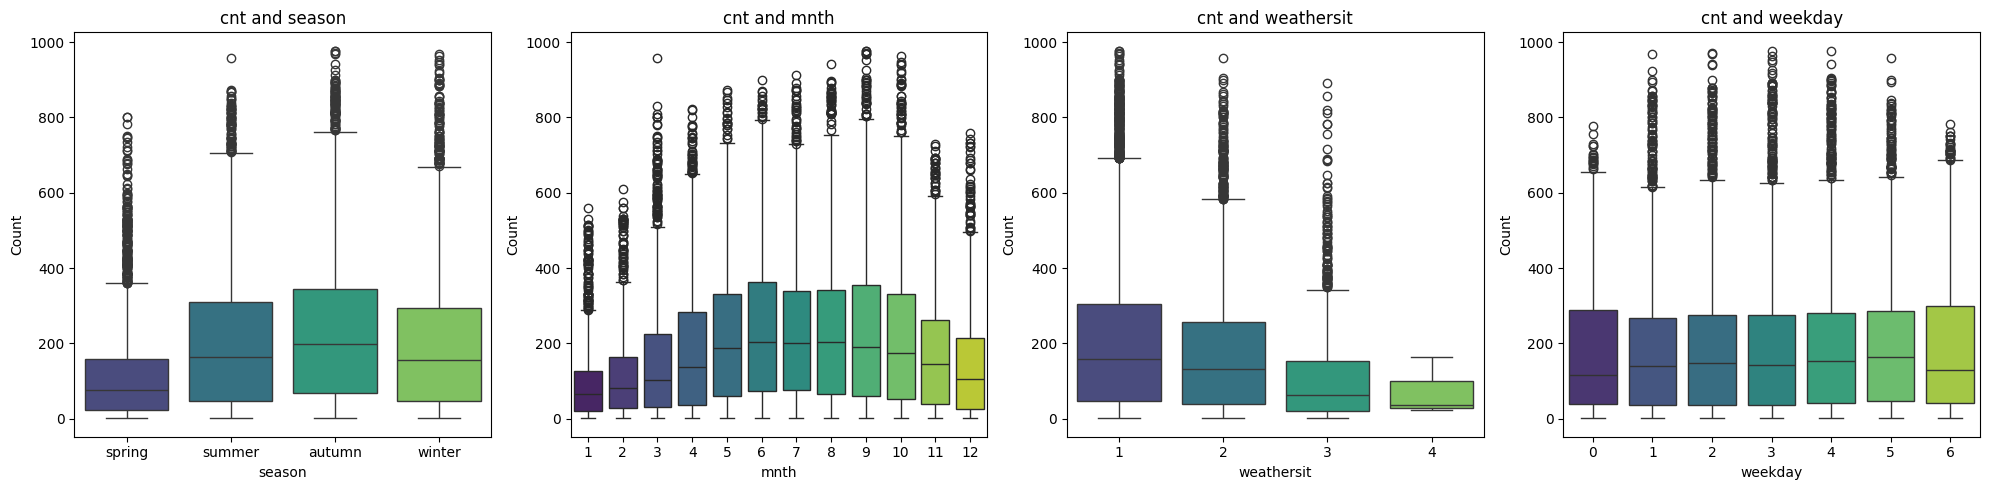

In [17]:
data_categorical = df[["season", "mnth", "weathersit", "weekday"]].copy()

fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for var, subplot in zip(data_categorical.columns, ax.flatten()):
    sns.boxplot(x=var, y=df["cnt"], data=df, palette='viridis', ax=subplot)
    subplot.set_title(f"cnt and {var}")
    subplot.set_ylabel('Count')

plt.tight_layout()
plt.show()

**Висновки з 11-12 завдання (детальні)**

11. Побудували графіки співвідношення scatterplot між числовими змінними та змінною cnt. За допомогою них можемо оцінити розподіл даних та можливі кореляції.

12. Побудували графіки співвідношення boxplot для категоріальних змінних. Тут можемо побачити розподіл у різних категоріях, наприклад season, mnth, weekday або weathersit.

**Завдання 13** Побудувати матрицю кореляції:  

1.   Вирахувати кореляційні коефіціенти для набору данних за методом Пірсона
2.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти  
3.   Вирахувати кореляційні коефіціенти для набору данних за методом Спірмана
4.   Відобразити отриману матрицю коефіціентів у вигляді теплокарти

5. Описати отримані результати, спираючись на значення коефіціентів кореляції та пояснити в чому відмінність обраних методів.

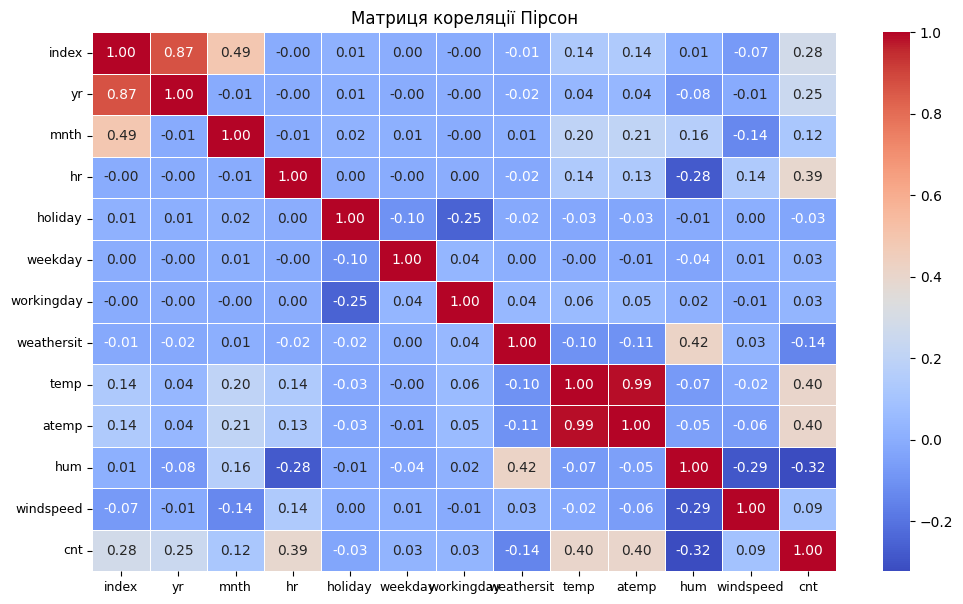

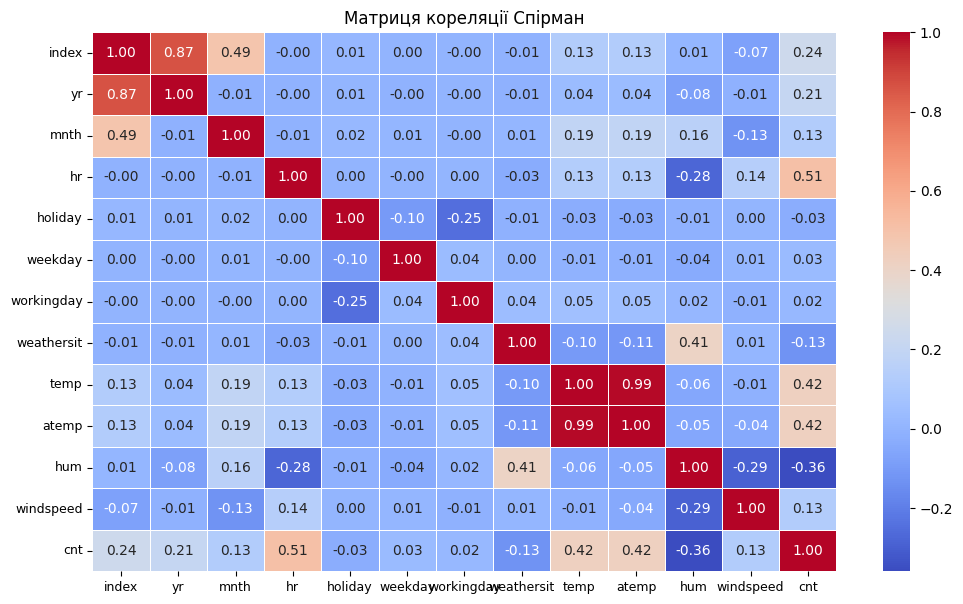

,index,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
index,1.000000,0.866014,0.489211,-0.004768,0.014723,0.001344,-0.003416,-0.007462,0.127947,0.126447,0.007488,-0.073236,0.243742
yr,0.866014,1.000000,-0.010429,-0.003861,0.006692,-0.004493,-0.002196,-0.013168,0.036441,0.035346,-0.083119,-0.010653,0.207500
mnth,0.489211,-0.010429,1.000000,-0.005737,0.018695,0.010293,-0.003653,0.008614,0.191369,0.190804,0.159684,-0.129945,0.125889
hr,-0.004768,-0.003861,-0.005737,1.000000,0.000477,-0.003497,0.002281,-0.030349,0.133998,0.132986,-0.278530,0.140367,0.510878
holiday,0.014723,0.006692,0.018695,0.000477,1.000000,-0.101857,-0.252471,-0.012917,-0.028125,-0.031468,-0.012288,0.004141,-0.029526
weekday,0.001344,-0.004493,0.010293,-0.003497,-0.101857,1.000000,0.035044,0.003277,-0.005724,-0.012979,-0.036598,0.009936,0.030297
workingday,-0.003416,-0.002196,-0.003653,0.002281,-0.252471,0.035044,1.000000,0.043875,0.054965,0.054103,0.017325,-0.010723,0.021033
weathersit,-0.007462,-0.013168,0.008614,-0.030349,-0.012917,0.003277,0.043875,1.000000,-0.104510,-0.111145,0.409364,0.008303,-0.126276
temp,0.127947,0.036441,0.191369,0.133998,-0.028125,-0.005724,0.054965,-0.104510,1.000000,0.989633,-0.055408,-0.009719,0.423330
atemp,0.126447,0.035346,0.190804,0.132986,-0.031468,-0.012979,0.054103,-0.111145,0.989633,1.000000,-0.052617,-0.041091,0.423258


In [25]:
correlation_matrix_pearson = data_numerical.corr(method='pearson')

plt.figure(figsize=(12, 7))
sns.heatmap(correlation_matrix_pearson, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(fontsize=9, rotation=0)
plt.yticks(fontsize=9)
plt.title("Матриця кореляції Пірсон")
plt.show()

correlation_matrix_pearson


correlation_matrix_spearman = data_numerical.corr(method='spearman')

plt.figure(figsize=(12, 7))
sns.heatmap(correlation_matrix_spearman, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.xticks(fontsize=9, rotation=0)
plt.yticks(fontsize=9)
plt.title("Матриця кореляції Спірман")
plt.show()

correlation_matrix_spearman

Між такими змінними як temp i atemp, yr i index є висока кореляція. Середня та слабка між weathersit i hum та windspeed i hum відповідно. Такі змінні як holiday, weekday i workingday мають дуже слабку кореляцію.

Основні відмінності між методами полягають у зв'язку. Також чутливість до аномалій, наприклад Пірсон більш чутливий.

**Завдання 14**
1. побудувати модель лінійної регресії:
2. видалити змінні, які НЕ є релевантними;

3. поділити вибірку на `train`, `test` та `validation` в пропорції `70/30`;  

4. провести навчання моделі лінійної регресії;

1. Для подальшої роботи з моделями для кожної категоріальної змінної ми створимо фіктивні змінні, щоб уникнути неправильного порядку категорій. [get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)

In [26]:
def get_dummies(df: pd.DataFrame):
    features = pd.concat([
        df,
        pd.get_dummies(df['season']),
        pd.get_dummies(df['mnth'], prefix='mnth'),
        pd.get_dummies(df['hr'], prefix='hr'),
        pd.get_dummies(df['weekday'], prefix='weekday'),
        pd.get_dummies(df['weathersit'], prefix='weathersit')
    ], axis=1)

    features = features.drop(['season', 'mnth', 'weekday', 'weathersit'], axis=1)

    return features

In [28]:
features = get_dummies(df)
features

,index,date,yr,hr,holiday,workingday,temp,atemp,hum,windspeed,...,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,1,1/1/11,0,0,0,0,0.24,0.2879,0.81,0.0000,...,False,False,False,False,False,True,True,False,False,False
1,2,1/1/11,0,1,0,0,0.22,0.2727,0.80,0.0000,...,False,False,False,False,False,True,True,False,False,False
2,3,1/1/11,0,2,0,0,0.22,0.2727,0.80,0.0000,...,False,False,False,False,False,True,True,False,False,False
3,4,1/1/11,0,3,0,0,0.24,0.2879,0.75,0.0000,...,False,False,False,False,False,True,True,False,False,False
4,5,1/1/11,0,4,0,0,0.24,0.2879,0.75,0.0000,...,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,12/31/12,1,19,0,1,0.26,0.2576,0.60,0.1642,...,True,False,False,False,False,False,False,True,False,False
17375,17376,12/31/12,1,20,0,1,0.26,0.2576,0.60,0.1642,...,True,False,False,False,False,False,False,True,False,False
17376,17377,12/31/12,1,21,0,1,0.26,0.2576,0.60,0.1642,...,True,False,False,False,False,False,True,False,False,False
17377,17378,12/31/12,1,22,0,1,0.26,0.2727,0.56,0.1343,...,True,False,False,False,False,False,True,False,False,False


2. На основі змінної часу створіть нову змінну, яка відповідатиме за день і ніч.

In [29]:
def is_night_hour(hour):
    return hour < 6 or hour >= 23

def add_night_hours_feature(df):
    df['night_hours'] = df['hr'].map(is_night_hour)
    return df.drop(columns=['hr'])

features = add_night_hours_feature(features)
features['night_hours'] = features['night_hours'].astype(int)
features

,index,date,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,...,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3,weathersit_4,night_hours
0,1,1/1/11,0,0,0,0.24,0.2879,0.81,0.0000,16,...,False,False,False,False,True,True,False,False,False,1
1,2,1/1/11,0,0,0,0.22,0.2727,0.80,0.0000,40,...,False,False,False,False,True,True,False,False,False,1
2,3,1/1/11,0,0,0,0.22,0.2727,0.80,0.0000,32,...,False,False,False,False,True,True,False,False,False,1
3,4,1/1/11,0,0,0,0.24,0.2879,0.75,0.0000,13,...,False,False,False,False,True,True,False,False,False,1
4,5,1/1/11,0,0,0,0.24,0.2879,0.75,0.0000,1,...,False,False,False,False,True,True,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,12/31/12,1,0,1,0.26,0.2576,0.60,0.1642,119,...,False,False,False,False,False,False,True,False,False,0
17375,17376,12/31/12,1,0,1,0.26,0.2576,0.60,0.1642,89,...,False,False,False,False,False,False,True,False,False,0
17376,17377,12/31/12,1,0,1,0.26,0.2576,0.60,0.1642,90,...,False,False,False,False,False,True,False,False,False,0
17377,17378,12/31/12,1,0,1,0.26,0.2727,0.56,0.1343,61,...,False,False,False,False,False,True,False,False,False,0


**Модель лінійної регрессії  

[train_linear_model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Після отримання фіктивних змінних потрібно видалити по одній з кожної категорії, щоб запобігти мультиколінеарності. Також видаляємо ще два атрибути `date` та `atemp` - поясніть чому?

In [30]:
features_lr = features.drop(['spring', 'mnth_4', 'weekday_0', 'weathersit_1', 'hr_0','atemp', 'date'], axis = 1)

In [35]:
def get_train_data(df: pd.DataFrame, target: str, test_size: float):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, shuffle=True)

    return X_train, X_test, y_train, y_test

In [32]:
X_train, X_test, y_train, y_test = get_train_data(features_lr, 'cnt', 0.3)

In [33]:
def train_linear_model(X_train, y_train):
  model = LinearRegression()
  model.fit(X_train, y_train)
  return model

model = train_linear_model(X_train, y_train)

In [36]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
print('MSE train: {:.3f}, test: {:.3f}'.format(
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)))
print('R^2 train: {:.3f}, test: {:.3f}'.format(
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)))

MSE train: 10448.098, test: 10101.710
R^2 train: 0.688, test: 0.680


Оскільки в нашій моделі є багато незалежних змінних, ми не можемо відобразити їх залежність у двовимірному просторі, але ми можемо побудувати графік взаємозв'язку між залишками моделі та передбачуваними значеннями, що також допоможе нам оцінити якість моделі.

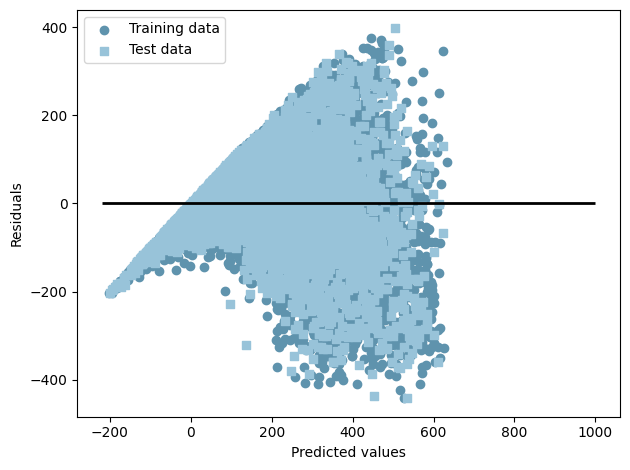

In [37]:
plt.scatter(y_train_pred,  y_train_pred - y_train,
            c='#5f93ad', marker='o', label='Training data')
plt.scatter(y_test_pred,  y_test_pred - y_test,
            c='#98c3d9', marker='s', label='Test data')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.legend(loc='upper left')
plt.hlines(y=0, xmin=-220, xmax=1000, lw=2, color='#000000')
plt.tight_layout()

**Висновки з завдання (детальні)**

Створили night_hours та закодували категоріальні ознаки. Також у нас майже немає лінійних зв'язків.
Лінійна регресія на 70% даних.
Також отримали випадкові залишки:
MSE train: 10448.098, test: 10101.710
R^2 train: 0.688, test: 0.680
